In [1]:
import pandas as pd
import numpy as np
import uuid
from typing import Tuple

from sklearn.metrics import mean_squared_error

import pymc as pm
import xarray as xr
import arviz as az
import arviz_plots as azp

import matplotlib.pyplot as plt
RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

pandas: 3.0.5
numpy: 2.4.3
pymc: 6.2.0
pytensor: 3.2.4
arviz: 1.3.0
arviz_plots: 1.3.0


In [2]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs)-> xr.DataTree:
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        xr.DataTree.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling

    Returns:
        xr.DataTree: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [3]:
# first use handy index function
def define_index(data: pd.DataFrame, label: str) -> Tuple[np.array, dict]:
    """Defines an index variable starting at 0.
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values.astype("int32")
    return index_vals, lookup

def map_index(data: pd.DataFrame, label: str, lookup_dict: dict) -> np.array:
    """Applies an index to new values
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format
        lookup_dict (dict): dictionary that contains the mappings from inputs to index

    Returns:
        np.array: indexed values
    """
    s = data[label].astype(str)
    vals = s.map(lookup_dict).values
    return vals

In [4]:
# import data
df = pd.read_csv('data/bat_speed_model_data_monthly.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')
df.head()

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,bips,ev90,latent_ev90_mean,latent_ev90_std,swing_total,bat_speed,imputed_bat_speed,model_bat_speed,is_imputed,is_complete
0,120074,2016,Mar/Apr,0,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,62.0,107.51,106.923259,0.669996,168.0,NaN,73.490941,73.490941,1,0
1,120074,2016,May,1,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,78.0,108.94,106.961690,0.641453,193.0,NaN,73.524456,73.524456,1,0
2,120074,2016,Jun,2,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,73.0,105.84,106.920999,0.627866,176.0,NaN,73.491806,73.491806,1,0
3,120074,2016,Jul,3,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,76.0,106.45,106.918319,0.637789,181.0,NaN,73.488981,73.488981,1,0
4,120074,2016,Aug,4,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,79.0,107.94,106.938944,0.660242,180.0,NaN,73.506715,73.506715,1,0


In [5]:
# test data will be all of 2025 to present
train_df = df.loc[df['year']<2025].reset_index(drop=True)
test_df = df.loc[df['year']>=2025].reset_index(drop=True)
print(train_df.shape[0])
print(test_df.shape[0])

seen_players = set(train_df["player_full_id"])
test_df["seen_player"] = test_df["player_full_id"].isin(seen_players)
test_seen = test_df.loc[test_df["seen_player"]].copy()
test_unseen = test_df.loc[~test_df["seen_player"]].copy()
print(test_seen["player_full_id"].unique().shape[0])
print(test_unseen["player_full_id"].unique().shape[0])

23793
5204
580
194


In [6]:
# standardize age
age_mean = np.mean(train_df['age'])
age_std = np.std(train_df['age'])
train_df['age_z'] = (train_df['age'] - age_mean)/age_std
test_df['age_z'] = (test_df['age'] - age_mean)/age_std

# define age and age squared for the model
age_values = train_df['age_z'].values
age_sq_values = age_values**2

n_obs = len(train_df)
train_df["player_idx"], player_lookup = define_index(train_df, "player_full_id")
player_idx_vals = train_df['player_idx'].values.astype("int32")
player_name_list = list(player_lookup.keys())
is_imputed_data_vals = train_df['is_imputed'].values.astype("int32")

bat_speed_target = train_df['model_bat_speed'].values
swings_sqrt_values = np.sqrt(train_df['swing_total'].values)

# define emprical prior for bat speed
prior_mean = np.mean(bat_speed_target)
prior_std = np.std(bat_speed_target)
print(prior_mean)
print(prior_std)


69.84286124890633
2.6224484184870502


In [7]:
# grp = df.groupby(["year","month_name"]).agg(
#     mean=("model_bat_speed", "mean"),
#     std=("model_bat_speed", "std"),
#     count=("model_bat_speed", "count"),
#     is_imputed=("is_imputed", "min")
#     ).reset_index()
# grp["month_name"] = pd.Categorical(grp["month_name"], categories=['Mar/Apr','May','Jun','Jul','Aug','Sep/Oct'], ordered=True)
# grp_sorted = grp.sort_values(["year","month_name"]).reset_index(drop=True)
# grp_sorted["x"] = grp_sorted["year"].astype(str) + "-" + grp_sorted["month_name"].astype(str)
# obs_mask = grp_sorted["is_imputed"] == 0
# imp_mask = ~obs_mask

# fig, ax = plt.subplots(figsize=(10,5))
# ax.plot(grp_sorted["x"], grp_sorted["mean"], color="gray", alpha=0.5, zorder=1)
# ax.scatter(grp_sorted.loc[imp_mask, "x"], grp_sorted.loc[imp_mask, "mean"], color="orange", label="Imputed", zorder=3)
# ax.scatter(grp_sorted.loc[obs_mask, "x"], grp_sorted.loc[obs_mask, "mean"], color="blue", label="Observed", zorder=3)
# ax.fill_between(range(len(grp_sorted)), grp_sorted["mean"] - grp_sorted["std"], grp_sorted["mean"] + grp_sorted["std"], where=imp_mask, color="orange", alpha=0.2)
# ax.fill_between(range(len(grp_sorted)), grp_sorted["mean"] - grp_sorted["std"], grp_sorted["mean"] + grp_sorted["std"], where=obs_mask, color="blue", alpha=0.2)
# ax.axvline(x=grp_sorted[grp_sorted["year"]==2025].index.min(), color="red")
# ax.set_xticks([])
# ax.legend(loc="upper left")
# plt.tight_layout()
# plt.show()

<Axes: >

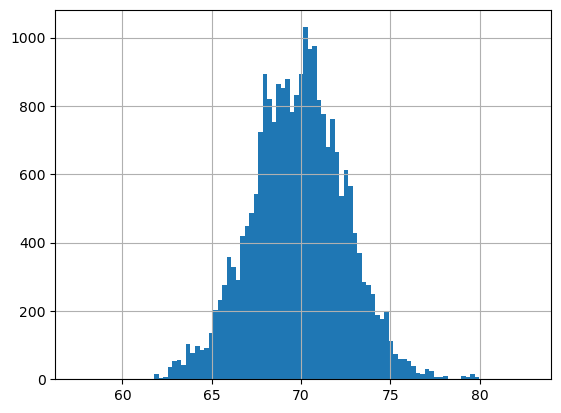

In [8]:
train_df['model_bat_speed'].hist(bins=100)

In [9]:
print(prior_mean+prior_std*1.25*3)
print(prior_mean-prior_std*1.25*3)

assert(np.isnan(swings_sqrt_values).sum() == 0)

79.67704281823276
60.00867967957989


In [10]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
}   

# pymc model
with pm.Model(coords=coords) as model_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_values, dims=("observation_id",))
    age_sq_data = pm.Data('age_sq_data', age_sq_values, dims=("observation_id",))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # player random
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop, sigma=sigma_player, dims=("player",))
    
    # age
    a = pm.Normal("a", mu=0, sigma=1)
    b = pm.Normal("b", mu=0, sigma=1)
    f = pm.Deterministic('f', a*age_sq_data + b*age_data)

    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [11]:
trace_quad = sample(model_quad, draws = 2000, tune = 2000, target_accept = 0.99,  path='quad_model.nc')

NUTS[nutpie]: [mu_pop, sigma_player, mu_player, a, b, sigma_imputed, sigma_observed]


Output()

In [12]:
az.summary(trace_quad, var_names=['mu_pop', 'sigma_player', 'a', 'b', 'sigma_imputed', 'sigma_observed'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_pop,69.44,0.07,69.31,69.57,14356.03,6133.52,1.0,0.0,0.0
sigma_player,2.47,0.05,2.38,2.56,13299.79,6077.78,1.0,0.0,0.0
a,-0.13,0.00,-0.13,-0.12,2278.48,3418.95,1.0,0.0,0.0
b,0.03,0.01,0.01,0.04,1769.02,2890.84,1.0,0.0,0.0
sigma_imputed,4.82,0.03,4.77,4.87,13968.92,6319.79,1.0,0.0,0.0
sigma_observed,14.14,0.16,13.84,14.45,12126.07,6033.61,1.0,0.0,0.0


In [13]:
az.summary(trace_quad, var_names=['mu_player'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_player[David Ortiz (120074)],74.73,0.15,74.43,75.02,8711.98,5692.34,1.0,0.00,0.00
mu_player[Alex Rodriguez (121347)],72.92,0.23,72.47,73.38,12289.87,5673.24,1.0,0.00,0.00
mu_player[Adrian Beltré (134181)],70.26,0.10,70.07,70.45,9131.83,5314.58,1.0,0.00,0.00
mu_player[Carlos Beltrán (136860)],71.28,0.11,71.06,71.51,8770.25,5686.86,1.0,0.00,0.00
mu_player[Jayson Werth (150029)],72.24,0.12,71.99,72.48,11661.53,5866.93,1.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...
mu_player[Jackson Holliday (702616)],71.04,0.71,69.64,72.46,16284.23,6114.02,1.0,0.01,0.00
mu_player[Nacho Alvarez Jr. (805373)],68.89,1.52,65.93,71.87,16756.48,5743.55,1.0,0.01,0.01
mu_player[Jacob Wilson (805779)],64.31,1.01,62.28,66.27,17280.07,6150.84,1.0,0.01,0.01
mu_player[Masataka Yoshida (807799)],70.73,0.19,70.36,71.10,18857.54,6491.80,1.0,0.00,0.00


In [14]:
def plot_aging_curve(trace, age_z, model_name="Model"):
    f_draws = trace.posterior["f"].values
    curves = f_draws.reshape(-1, f_draws.shape[-1])

    sort_idx = np.argsort(age_z)
    age_sorted = age_z[sort_idx]
    curves_sorted = curves[:, sort_idx]

    _, ax = plt.subplots(figsize=(8, 6))
    rng = np.random.default_rng(RANDOM_SEED)
    subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
    for idx in subset_indices:
        ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

    ax.set_title(f"{model_name} Aging Curve")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Bat Speed Change (mph)")
    ax.set_ylim(-3, 1)
    ax.grid(True)
    plt.show()
    return curves_sorted

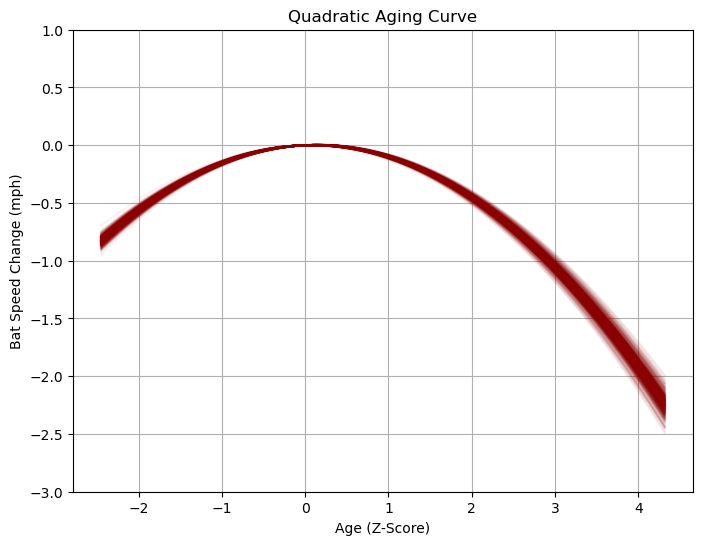

In [15]:
quad_aging_curve = plot_aging_curve(trace_quad, age_values, model_name="Quadratic")

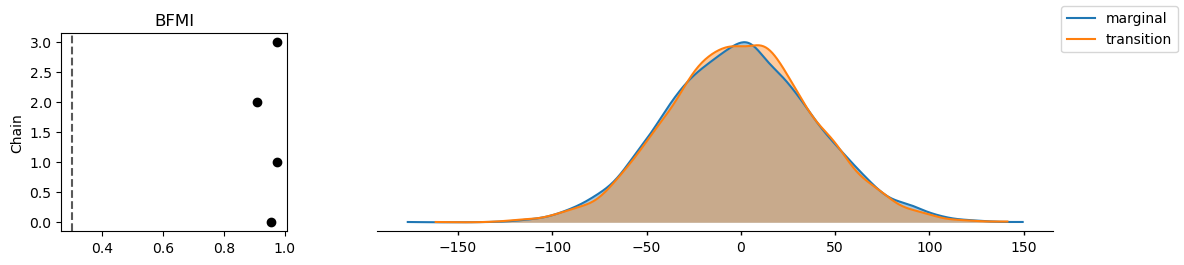

In [16]:
az.plot_energy(trace_quad)

In [17]:
spp = sample_posterior_pred(model_quad, trace_quad)

Sampling: [target]


Output()

Text(0.5, 0, 'Bat Speed (mph)')

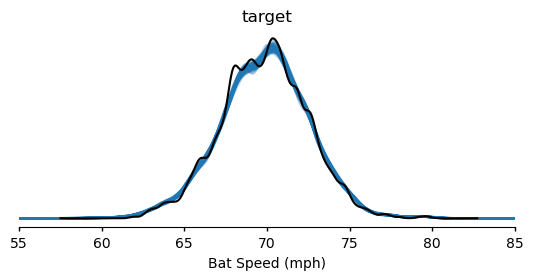

In [18]:
pc = azp.plot_ppc_dist(spp, var_names="target", num_samples=100)
ax = pc.viz["plot"]["target"].item()
ax.set_xlim(55, 85)
ax.set_xlabel("Bat Speed (mph)")

In [19]:
a_posterior_mean = trace_quad.posterior['a'].mean(dim=("chain", "draw")).values.flatten()
b_posterior_mean = trace_quad.posterior['b'].mean(dim=("chain", "draw")).values.flatten()
a_posterior_std = trace_quad.posterior['a'].std(dim=("chain", "draw")).values.flatten()
b_posterior_std = trace_quad.posterior['b'].std(dim=("chain", "draw")).values.flatten()

In [20]:
def make_preds(model, trace, df, player_lookup):
    with model:
        pm.set_data(
            {
                "player_idx": df["player_idx"].values.astype("int32"),
                "age_data": df["age_z"].values,
                "age_sq_data": df["age_z"].values**2,
                "swings_sqrt": np.sqrt(df["swing_total"].values),
                "is_imputed_data": df["is_imputed"].values,
                "target_data": np.zeros(len(df)),
            },
            coords={
                "observation_id": np.arange(len(df)),
                "player": list(player_lookup.keys()),
            },
        )
        spp = pm.sample_posterior_predictive(
            trace,
            var_names=["target"],
            predictions=True,
            random_seed=RANDOM_SEED,
            return_inferencedata=False,
        )
    return spp


def make_preds_quadratic(model, trace, df, player_lookup):
    df = df.reset_index(drop=True)
    df["player_idx"] = map_index(df, "player_full_id", player_lookup)
    seen = df["player_idx"].notna().values

    n_obs = len(df)
    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    preds = np.empty((n_samples, n_obs))

    if seen.any():
        seen_df = df[seen]
        spp = make_preds(model, trace, seen_df, player_lookup)
        target_arr = spp["target"]
        n_chains, n_draws = target_arr.shape[0], target_arr.shape[1]
        preds[:, seen] = target_arr.reshape(n_chains * n_draws, -1)

    if (~seen).any():
        unseen_df = df[~seen]
        age = unseen_df["age_z"].values
        age_sq = age**2
        swings_sqrt = np.sqrt(unseen_df["swing_total"].values)
        is_imputed = unseen_df["is_imputed"].values

        mu_pop = post["mu_pop"].values.reshape(-1)
        sigma_player = post["sigma_player"].values.reshape(-1)
        a = post["a"].values.reshape(-1)
        b = post["b"].values.reshape(-1)
        sigma_imputed = post["sigma_imputed"].values.reshape(-1)
        sigma_observed = post["sigma_observed"].values.reshape(-1)

        rng = np.random.default_rng(RANDOM_SEED)
        uniq_players, inv = np.unique(unseen_df["player_full_id"].values, return_inverse=True)
        n_uniq = len(uniq_players)
        mu_player_new = rng.normal(mu_pop[:, None], sigma_player[:, None], size=(n_samples, n_uniq))
        mu_player_row = mu_player_new[:, inv]

        f = a[:, None] * age_sq[None, :] + b[:, None] * age[None, :]
        theta = mu_player_row + f

        sigma = np.where(
            is_imputed[None, :],
            sigma_imputed[:, None],
            sigma_observed[:, None],
        )
        preds[:, ~seen] = rng.normal(theta, sigma / swings_sqrt[None, :])

    return preds, seen

In [21]:
def validate_preds(preds, seen, df):
    y = df['model_bat_speed'].values
    seen = np.asarray(seen, dtype=bool)
    def score_output(mask):
        y_i = y[mask]
        p_i = preds[:, mask]
        pred_mean = p_i.mean(axis=0)
        lower_95, upper_95 = np.quantile(p_i, [0.025, 0.975], axis=0)

        return {
            "n": int(len(y_i)),
            "rmse": float(round(np.sqrt(mean_squared_error(y_i, pred_mean)), 4)),
            "coverage_95": float(round(np.mean((y_i >= lower_95) & (y_i <= upper_95)), 4)),
        }

    return {
        "overall": score_output(np.ones(len(y), dtype=bool)),
        "seen": score_output(seen) if seen.any() else None,
        "unseen": score_output(~seen) if (~seen).any() else None,
    }

In [22]:
quad_preds, seen = make_preds_quadratic(model_quad, trace_quad, train_df, player_lookup)
validate_preds(quad_preds, seen, train_df)

Sampling: [target]


Output()

{'overall': {'n': 23793, 'rmse': 0.782, 'coverage_95': 0.9448},
 'seen': {'n': 23793, 'rmse': 0.782, 'coverage_95': 0.9448},
 'unseen': None}

In [23]:
quad_preds, seen = make_preds_quadratic(model_quad, trace_quad, test_df, player_lookup)
validate_preds(quad_preds, seen, test_df)

Sampling: [target]


Output()

{'overall': {'n': 5204, 'rmse': 2.1326, 'coverage_95': 0.9105},
 'seen': {'n': 4352, 'rmse': 1.7736, 'coverage_95': 0.9088},
 'unseen': {'n': 852, 'rmse': 3.4221, 'coverage_95': 0.919}}

In [24]:
# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_values), np.max(age_values)],
    lengthscale_range=[0.75, 1.25],
    cov_func="expquad",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 9, c: 1.20


In [25]:
class QuadraticMean(pm.gp.mean.Mean):
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def __call__(self, X):
        x = X[:, 0]
        return self.a * x**2 + self.b * x

In [26]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list
}

with pm.Model(coords=coords) as model_gp_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data("age_data", age_values.reshape(-1, 1))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # player random
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop, sigma=sigma_player, dims=("player",))
    
    # priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std)
    mean = QuadraticMean(a, b)
    # covariance priors
    eta = pm.HalfNormal("eta", 0.25)
    ls = pm.InverseGamma("ls", alpha=15, beta=14)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls)
    # HSGP
    gp_quad = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp_quad.prior("f", X=age_data)

    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

Sampling: [a, b, eta, f_hsgp_coeffs, ls]


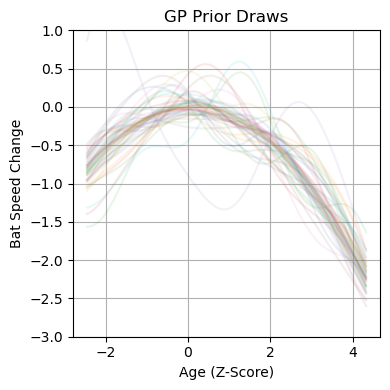

In [27]:
with model_gp_quad:
    prior_samples = pm.sample_prior_predictive(var_names=["eta", "ls", "f"], random_seed=RANDOM_SEED, draws=50)

fig, ax = plt.subplots(figsize=(4, 4))
rng = np.random.default_rng(RANDOM_SEED)
sort_idx = np.argsort(age_values)
gp_draws = prior_samples.prior["f"].values[..., :].reshape(-1, len(age_values))
draw_idx = rng.choice(gp_draws.shape[0], size=min(100, gp_draws.shape[0]), replace=False)
for draw in gp_draws[draw_idx]:
    ax.plot(age_values[sort_idx], draw[sort_idx], alpha=0.1)
ax.set_title(f"GP Prior Draws")
ax.set_ylim(-3,1)
ax.set_xlabel("Age (Z-Score)")
ax.set_ylabel("Bat Speed Change")
ax.grid(True)

plt.tight_layout()
plt.show()

In [28]:
trace_gp_quad = sample(model_gp_quad, draws = 2000, tune = 3000, target_accept = 0.99,  path='gp_expquad_quadratic.nc')

NUTS[nutpie]: [mu_pop, sigma_player, mu_player, a, b, eta, ls, f_hsgp_coeffs, sigma_imputed, sigma_observed]


Output()

In [29]:
az.summary(trace_gp_quad, var_names=['eta','ls','mu_pop','sigma_player','a','b','sigma_imputed','sigma_observed'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta,0.22,0.08,0.11,0.42,402.18,859.94,1.01,0.0,0.0
ls,0.71,0.11,0.51,0.94,844.43,1303.26,1.00,0.0,0.0
mu_pop,69.43,0.07,69.29,69.56,1647.53,3881.12,1.00,0.0,0.0
sigma_player,2.47,0.05,2.38,2.56,9041.76,6163.63,1.00,0.0,0.0
a[0],-0.13,0.00,-0.14,-0.12,372.48,753.83,1.01,0.0,0.0
b[0],0.03,0.01,0.02,0.05,1444.63,2402.69,1.00,0.0,0.0
sigma_imputed,4.80,0.02,4.75,4.85,9085.29,6340.22,1.00,0.0,0.0
sigma_observed,14.17,0.16,13.87,14.48,8009.69,6199.64,1.00,0.0,0.0


In [30]:
az.summary(trace_gp_quad, var_names=['mu_player'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_player[David Ortiz (120074)],74.83,0.16,74.53,75.14,5368.02,5115.30,1.0,0.00,0.00
mu_player[Alex Rodriguez (121347)],73.05,0.23,72.59,73.51,8096.21,6328.14,1.0,0.00,0.00
mu_player[Adrian Beltré (134181)],70.14,0.10,69.95,70.33,5209.50,4891.85,1.0,0.00,0.00
mu_player[Carlos Beltrán (136860)],71.29,0.12,71.06,71.53,3695.98,4799.52,1.0,0.00,0.00
mu_player[Jayson Werth (150029)],72.07,0.13,71.83,72.33,7290.85,5666.97,1.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...
mu_player[Jackson Holliday (702616)],71.22,0.71,69.82,72.63,9871.83,5698.73,1.0,0.01,0.01
mu_player[Nacho Alvarez Jr. (805373)],68.94,1.55,65.91,71.99,11361.96,6379.95,1.0,0.01,0.01
mu_player[Jacob Wilson (805779)],64.34,1.05,62.23,66.42,11448.54,5777.60,1.0,0.01,0.01
mu_player[Masataka Yoshida (807799)],70.70,0.20,70.32,71.08,8835.33,6071.64,1.0,0.00,0.00


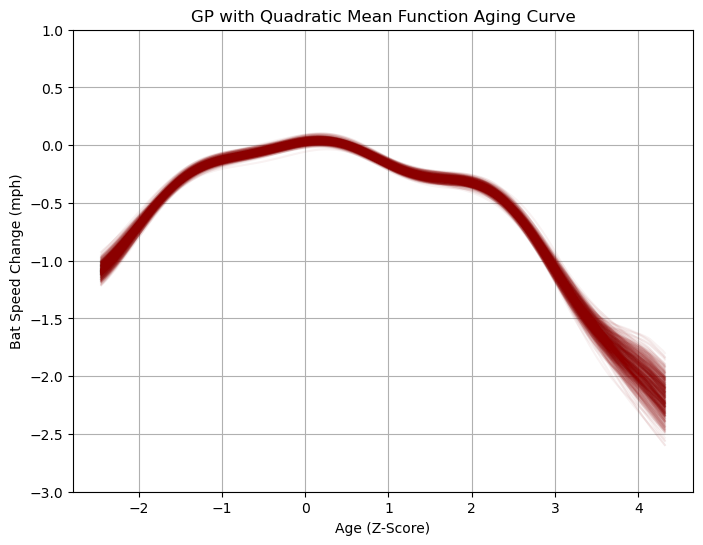

In [31]:
gp_aging_curve = plot_aging_curve(trace_gp_quad, age_values, model_name="GP with Quadratic Mean Function")

In [32]:
def predict_f(model, gp, trace, age_new, label="new"):
    age_new_2d = np.asarray(age_new).reshape(-1, 1)
    with model:
        f_new = gp.conditional(f"f_{label}", Xnew=age_new_2d)
        pred = pm.sample_posterior_predictive(
            trace,
            var_names=[f"f_{label}"],
            predictions=True,
            random_seed=RANDOM_SEED,
        )
    n_samples = pred.predictions.sizes["chain"] * pred.predictions.sizes["draw"]
    return pred.predictions[f"f_{label}"].values.reshape(n_samples, -1)

def make_preds_gp_seen(model, gp, trace, df, label):
    age_new = df["age_z"].values
    f_samples = predict_f(model, gp, trace, age_new, label=f"{label}_seen")
    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    mu_player = post["mu_player"].values.reshape(n_samples, -1)
    player_idx = df["player_idx"].values.astype(int)
    theta = mu_player[:, player_idx] + f_samples

    sigma_imputed = post["sigma_imputed"].values.reshape(-1)
    sigma_observed = post["sigma_observed"].values.reshape(-1)
    is_imputed = df["is_imputed"].values
    sigma = np.where(is_imputed[None, :], sigma_imputed[:, None], sigma_observed[:, None])
    swings_sqrt = np.sqrt(df["swing_total"].values)

    rng = np.random.default_rng(RANDOM_SEED)
    return rng.normal(theta, sigma / swings_sqrt[None, :])


def make_preds_gp(model, gp, trace, df, player_lookup, label=None):
    if label is None:
        label = uuid.uuid4().hex[:8]
    df = df.reset_index(drop=True)
    df['player_idx'] = map_index(df, "player_full_id", player_lookup)
    seen = df['player_idx'].notna().values

    n_obs = len(df)
    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    preds = np.empty((n_samples, n_obs))

    if seen.any():
        seen_df = df[seen]
        preds[:, seen] = make_preds_gp_seen(model, gp, trace, seen_df, label)

    if (~seen).any():
        unseen_df = df[~seen]
        age_new = unseen_df["age_z"].values  # 1D, not column_stack
        swings_sqrt = np.sqrt(unseen_df["swing_total"].values)
        is_imputed = unseen_df["is_imputed"].values
        f_samples = predict_f(model, gp, trace, age_new, label=f"{label}_unseen")

        mu_pop = post["mu_pop"].values.reshape(-1)
        sigma_player = post["sigma_player"].values.reshape(-1)
        sigma_imputed = post["sigma_imputed"].values.reshape(-1)
        sigma_observed = post["sigma_observed"].values.reshape(-1)

        rng = np.random.default_rng(RANDOM_SEED)
        uniq_players, inv = np.unique(unseen_df["player_full_id"].values, return_inverse=True)
        n_uniq = len(uniq_players)
        mu_player_new = rng.normal(mu_pop[:, None], sigma_player[:, None], size=(n_samples, n_uniq))
        mu_player_row = mu_player_new[:, inv]

        theta = mu_player_row + f_samples
        sigma = np.where(is_imputed[None, :], sigma_imputed[:, None], sigma_observed[:, None])
        preds[:, ~seen] = rng.normal(theta, sigma / swings_sqrt[None, :])

    return preds, seen

In [33]:
gp_preds, seen = make_preds_gp(model_gp_quad, gp_quad, trace_gp_quad, train_df, player_lookup, label="train")
validate_preds(gp_preds, seen, train_df)

Sampling: []


Output()

{'overall': {'n': 23793, 'rmse': 0.782, 'coverage_95': 0.9452},
 'seen': {'n': 23793, 'rmse': 0.782, 'coverage_95': 0.9452},
 'unseen': None}

In [34]:
gp_preds, seen = make_preds_gp(model_gp_quad, gp_quad, trace_gp_quad, test_df, player_lookup, label="test")
validate_preds(gp_preds, seen, test_df)

Sampling: []


Output()

Sampling: []


Output()

{'overall': {'n': 5204, 'rmse': 2.1328, 'coverage_95': 0.9105},
 'seen': {'n': 4352, 'rmse': 1.7722, 'coverage_95': 0.9088},
 'unseen': {'n': 852, 'rmse': 3.4266, 'coverage_95': 0.919}}

In [ ]:
# add position
pdf = train_df[['bam_id','player_full_id','full','position','position_hybrid']].drop_duplicates(['player_full_id']).reset_index(drop=True)
pdf["position_idx"], position_lookup = define_index(pdf, "position")
position_idx_vals = pdf['position_idx'].values.astype("int32")
position_name_list = list(position_lookup.keys())
pdf.head()

,bam_id,player_full_id,full,position,position_hybrid,position_idx
0,120074,David Ortiz (120074),David Ortiz,DH,DH,0
1,121347,Alex Rodriguez (121347),Alex Rodriguez,SS,UTM,1
2,134181,Adrian Beltré (134181),Adrian Beltré,3B,CINF,2
3,136860,Carlos Beltrán (136860),Carlos Beltrán,CF,UTM,3
4,150029,Jayson Werth (150029),Jayson Werth,RF,COF,4


In [36]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "position": position_name_list
}

with pm.Model(coords=coords) as model_gp_position:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data("age_data", age_values.reshape(-1, 1))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    position_idx = pm.Data('position_idx', position_idx_vals, dims=('player',))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # position
    sigma_position = pm.HalfNormal("sigma_position", 1.0)
    position_effect = pm.ZeroSumNormal("position_effect", sigma=sigma_position, dims="position")
    # player
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop + position_effect[position_idx], sigma=sigma_player, dims=("player",))
    
    # priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std)
    mean = QuadraticMean(a, b)
    # covariance priors
    eta = pm.HalfNormal("eta", 0.25)
    ls = pm.InverseGamma("ls", alpha=15, beta=14)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls)
    # HSGP
    gp_position = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp_position.prior("f", X=age_data)
    
    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [37]:
trace_gp_position = sample(model_gp_position, draws = 2000, tune = 3000, target_accept = 0.99,  path='gp_expquad_quadratic_position.nc')

NUTS[nutpie]: [mu_pop, sigma_position, position_effect, sigma_player, mu_player, a, b, eta, ls, f_hsgp_coeffs, sigma_imputed, sigma_observed]


Output()

In [38]:
az.summary(trace_gp_position, var_names=['eta','ls','mu_pop','sigma_player','a','b','sigma_imputed','sigma_observed',
                                         'sigma_position','position_effect'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta,0.22,0.08,0.11,0.42,380.92,798.49,1.01,0.00,0.00
ls,0.71,0.11,0.50,0.94,556.21,1129.38,1.01,0.00,0.00
mu_pop,69.60,0.08,69.46,69.75,1841.24,3210.86,1.00,0.00,0.00
sigma_player,2.28,0.04,2.19,2.36,9071.90,6087.97,1.00,0.00,0.00
a[0],-0.13,0.00,-0.14,-0.12,346.35,698.85,1.02,0.00,0.00
b[0],0.03,0.01,0.02,0.05,1381.18,2934.92,1.00,0.00,0.00
sigma_imputed,4.80,0.03,4.75,4.85,8883.57,6319.25,1.00,0.00,0.00
sigma_observed,14.18,0.16,13.87,14.49,8475.31,6277.25,1.00,0.00,0.00
sigma_position,1.17,0.27,0.76,1.82,8514.40,5994.97,1.00,0.00,0.00
position_effect[DH],2.09,0.29,1.52,2.66,8377.47,6368.32,1.00,0.00,0.00


In [39]:
az.summary(trace_gp_quad, var_names=['mu_player'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_player[David Ortiz (120074)],74.83,0.16,74.53,75.14,5368.02,5115.30,1.0,0.00,0.00
mu_player[Alex Rodriguez (121347)],73.05,0.23,72.59,73.51,8096.21,6328.14,1.0,0.00,0.00
mu_player[Adrian Beltré (134181)],70.14,0.10,69.95,70.33,5209.50,4891.85,1.0,0.00,0.00
mu_player[Carlos Beltrán (136860)],71.29,0.12,71.06,71.53,3695.98,4799.52,1.0,0.00,0.00
mu_player[Jayson Werth (150029)],72.07,0.13,71.83,72.33,7290.85,5666.97,1.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...
mu_player[Jackson Holliday (702616)],71.22,0.71,69.82,72.63,9871.83,5698.73,1.0,0.01,0.01
mu_player[Nacho Alvarez Jr. (805373)],68.94,1.55,65.91,71.99,11361.96,6379.95,1.0,0.01,0.01
mu_player[Jacob Wilson (805779)],64.34,1.05,62.23,66.42,11448.54,5777.60,1.0,0.01,0.01
mu_player[Masataka Yoshida (807799)],70.70,0.20,70.32,71.08,8835.33,6071.64,1.0,0.00,0.00


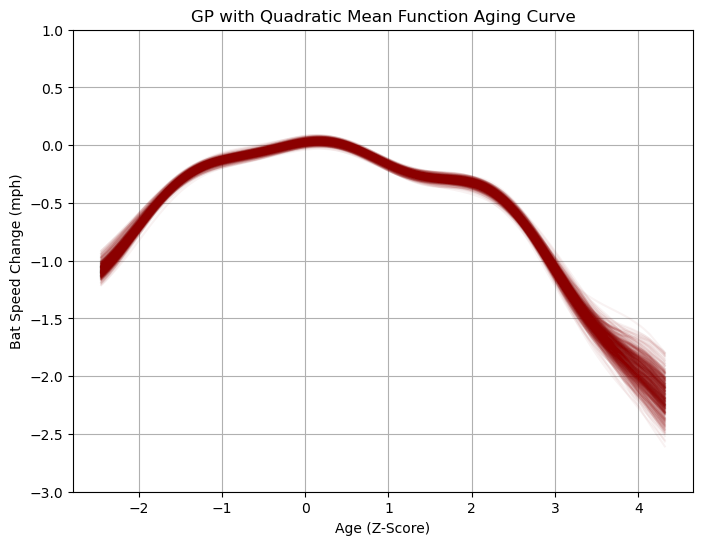

In [40]:
gp_aging_curve = plot_aging_curve(trace_gp_position, age_values, model_name="GP with Quadratic Mean Function")

In [41]:
def make_preds_gp_seen_position(model, gp, trace, df, label):
    age_new = df["age_z"].values
    f_samples = predict_f(model, gp, trace, age_new, label=f"{label}_seen")

    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    mu_player = post["mu_player"].values.reshape(n_samples, -1)
    player_idx = df["player_idx"].values.astype(int)
    theta = mu_player[:, player_idx] + f_samples

    sigma_imputed = post["sigma_imputed"].values.reshape(-1)
    sigma_observed = post["sigma_observed"].values.reshape(-1)
    is_imputed = df["is_imputed"].values
    sigma = np.where(is_imputed[None, :], sigma_imputed[:, None], sigma_observed[:, None])
    swings_sqrt = np.sqrt(df["swing_total"].values)

    rng = np.random.default_rng(RANDOM_SEED)
    return rng.normal(theta, sigma / swings_sqrt[None, :])


def make_preds_gp_position(model, gp, trace, df, player_lookup, position_lookup, label=None):
    if label is None:
        label = uuid.uuid4().hex[:8]

    df = df.reset_index(drop=True)
    df['player_idx'] = map_index(df, "player_full_id", player_lookup)
    df['position_idx'] = map_index(df, "position", position_lookup)
    seen = df['player_idx'].notna().values

    n_obs = len(df)
    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    preds = np.empty((n_samples, n_obs))

    if seen.any():
        seen_df = df[seen]
        preds[:, seen] = make_preds_gp_seen_position(model, gp, trace, seen_df, label)

    if (~seen).any():
        unseen_df = df[~seen]
        age_new = unseen_df["age_z"].values
        swings_sqrt = np.sqrt(unseen_df["swing_total"].values)
        is_imputed = unseen_df["is_imputed"].values
        f_samples = predict_f(model, gp, trace, age_new, label=f"{label}_unseen")

        mu_pop = post["mu_pop"].values.reshape(-1)
        sigma_player = post["sigma_player"].values.reshape(-1)
        sigma_imputed = post["sigma_imputed"].values.reshape(-1)
        sigma_observed = post["sigma_observed"].values.reshape(-1)
        position_effect = post["position_effect"].values.reshape(n_samples, -1)

        rng = np.random.default_rng(RANDOM_SEED)
        uniq_players, inv = np.unique(unseen_df["player_full_id"].values, return_inverse=True)
        n_uniq = len(uniq_players)

        pdf = unseen_df[['player_full_id', 'position_idx']].drop_duplicates(['player_full_id']).set_index('player_full_id').reindex(uniq_players)
        pos_idx_per_player = pdf['position_idx'].values.astype("int32")
        pos_eff_per_player = position_effect[:, pos_idx_per_player]

        mu_player_new = rng.normal(mu_pop[:, None] + pos_eff_per_player, sigma_player[:, None], size=(n_samples, n_uniq))
        mu_player_row = mu_player_new[:, inv]

        theta = mu_player_row + f_samples
        sigma = np.where(is_imputed[None, :], sigma_imputed[:, None], sigma_observed[:, None])
        preds[:, ~seen] = rng.normal(theta, sigma / swings_sqrt[None, :])

    return preds, seen

In [42]:
gp_preds, seen = make_preds_gp_position(model_gp_position, gp_position, trace_gp_position, train_df, player_lookup, position_lookup, label="train")
validate_preds(gp_preds, seen, train_df)

Sampling: []


Output()

{'overall': {'n': 23793, 'rmse': 0.7835, 'coverage_95': 0.9453},
 'seen': {'n': 23793, 'rmse': 0.7835, 'coverage_95': 0.9453},
 'unseen': None}

In [43]:
gp_preds, seen = make_preds_gp_position(model_gp_position, gp_position, trace_gp_position, test_df, player_lookup, position_lookup, label="test")
validate_preds(gp_preds, seen, test_df)

Sampling: []


Output()

Sampling: []


Output()

{'overall': {'n': 5204, 'rmse': 2.112, 'coverage_95': 0.9068},
 'seen': {'n': 4352, 'rmse': 1.7687, 'coverage_95': 0.9092},
 'unseen': {'n': 852, 'rmse': 3.3566, 'coverage_95': 0.8944}}

In [44]:
# add position
pdf = train_df[['bam_id','player_full_id','full','position','position_hybrid']].drop_duplicates(['player_full_id']).reset_index(drop=True)
pdf["position_idx"], position_lookup = define_index(pdf, "position_hybrid")
position_idx_vals = pdf['position_idx'].values.astype("int32")
position_name_list = list(position_lookup.keys())
pdf.head()

,bam_id,player_full_id,full,position,position_hybrid,position_idx
0,120074,David Ortiz (120074),David Ortiz,DH,DH,0
1,121347,Alex Rodriguez (121347),Alex Rodriguez,SS,UTM,1
2,134181,Adrian Beltré (134181),Adrian Beltré,3B,CINF,2
3,136860,Carlos Beltrán (136860),Carlos Beltrán,CF,UTM,1
4,150029,Jayson Werth (150029),Jayson Werth,RF,COF,3


In [52]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "position": position_name_list
}

with pm.Model(coords=coords) as model_gp_position:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data("age_data", age_values.reshape(-1, 1))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    position_idx = pm.Data('position_idx', position_idx_vals, dims=('player',))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # position
    sigma_position = pm.HalfNormal("sigma_position", 1.0)
    position_effect = pm.ZeroSumNormal("position_effect", sigma=sigma_position, dims="position")
    # player
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop + position_effect[position_idx], sigma=sigma_player, dims=("player",))
    
    # priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std)
    mean = QuadraticMean(a, b)
    # covariance priors
    eta = pm.HalfNormal("eta", 0.25)
    ls = pm.InverseGamma("ls", alpha=15, beta=14)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls)
    # HSGP
    gp_position = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp_position.prior("f", X=age_data)
    
    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [53]:
trace_gp_position = sample(model_gp_position, draws = 2000, tune = 3000, target_accept = 0.99,  path='gp_expquad_quadratic_position.nc')

NUTS[nutpie]: [mu_pop, sigma_position, position_effect, sigma_player, mu_player, a, b, eta, ls, f_hsgp_coeffs, sigma_imputed, sigma_observed]


Output()

In [54]:
az.summary(trace_gp_position, var_names=['eta','ls','mu_pop','sigma_player','a','b','sigma_imputed','sigma_observed',
                                         'sigma_position','position_effect'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta,0.22,0.08,0.11,0.41,403.71,633.37,1.00,0.0,0.0
ls,0.71,0.11,0.51,0.93,743.77,1221.77,1.00,0.0,0.0
mu_pop,69.86,0.09,69.70,70.03,2009.50,4274.28,1.00,0.0,0.0
sigma_player,2.31,0.04,2.22,2.40,9128.73,6048.05,1.00,0.0,0.0
a[0],-0.13,0.00,-0.14,-0.12,375.61,808.44,1.01,0.0,0.0
b[0],0.03,0.01,0.02,0.05,1535.46,2825.66,1.00,0.0,0.0
sigma_imputed,4.80,0.03,4.75,4.85,8346.63,5933.62,1.00,0.0,0.0
sigma_observed,14.18,0.16,13.88,14.49,8240.52,6133.19,1.00,0.0,0.0
sigma_position,1.31,0.39,0.73,2.22,9655.31,6138.18,1.00,0.0,0.0
position_effect[DH],1.87,0.26,1.36,2.39,4146.48,4977.13,1.00,0.0,0.0


In [55]:
def make_preds_gp_seen_position(model, gp, trace, df, label):
    age_new = df["age_z"].values
    f_samples = predict_f(model, gp, trace, age_new, label=f"{label}_seen")

    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    mu_player = post["mu_player"].values.reshape(n_samples, -1)
    player_idx = df["player_idx"].values.astype(int)
    theta = mu_player[:, player_idx] + f_samples

    sigma_imputed = post["sigma_imputed"].values.reshape(-1)
    sigma_observed = post["sigma_observed"].values.reshape(-1)
    is_imputed = df["is_imputed"].values
    sigma = np.where(is_imputed[None, :], sigma_imputed[:, None], sigma_observed[:, None])
    swings_sqrt = np.sqrt(df["swing_total"].values)

    rng = np.random.default_rng(RANDOM_SEED)
    return rng.normal(theta, sigma / swings_sqrt[None, :])


def make_preds_gp_position(model, gp, trace, df, player_lookup, position_lookup, label=None):
    if label is None:
        label = uuid.uuid4().hex[:8]

    df = df.reset_index(drop=True)
    df['player_idx'] = map_index(df, "player_full_id", player_lookup)
    df['position_idx'] = map_index(df, "position_hybrid", position_lookup)
    seen = df['player_idx'].notna().values

    n_obs = len(df)
    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    preds = np.empty((n_samples, n_obs))

    if seen.any():
        seen_df = df[seen]
        preds[:, seen] = make_preds_gp_seen_position(model, gp, trace, seen_df, label)

    if (~seen).any():
        unseen_df = df[~seen]
        age_new = unseen_df["age_z"].values
        swings_sqrt = np.sqrt(unseen_df["swing_total"].values)
        is_imputed = unseen_df["is_imputed"].values
        f_samples = predict_f(model, gp, trace, age_new, label=f"{label}_unseen")

        mu_pop = post["mu_pop"].values.reshape(-1)
        sigma_player = post["sigma_player"].values.reshape(-1)
        sigma_imputed = post["sigma_imputed"].values.reshape(-1)
        sigma_observed = post["sigma_observed"].values.reshape(-1)
        position_effect = post["position_effect"].values.reshape(n_samples, -1)

        rng = np.random.default_rng(RANDOM_SEED)
        uniq_players, inv = np.unique(unseen_df["player_full_id"].values, return_inverse=True)
        n_uniq = len(uniq_players)

        pdf = unseen_df[['player_full_id', 'position_idx']].drop_duplicates(['player_full_id']).set_index('player_full_id').reindex(uniq_players)
        pos_idx_per_player = pdf['position_idx'].values.astype("int32")
        pos_eff_per_player = position_effect[:, pos_idx_per_player]

        mu_player_new = rng.normal(mu_pop[:, None] + pos_eff_per_player, sigma_player[:, None], size=(n_samples, n_uniq))
        mu_player_row = mu_player_new[:, inv]

        theta = mu_player_row + f_samples
        sigma = np.where(is_imputed[None, :], sigma_imputed[:, None], sigma_observed[:, None])
        preds[:, ~seen] = rng.normal(theta, sigma / swings_sqrt[None, :])

    return preds, seen

In [56]:
gp_preds, seen = make_preds_gp_position(model_gp_position, gp_position, trace_gp_position, train_df, player_lookup, position_lookup, label="train")
validate_preds(gp_preds, seen, train_df)

Sampling: []


Output()

{'overall': {'n': 23793, 'rmse': 0.7834, 'coverage_95': 0.9449},
 'seen': {'n': 23793, 'rmse': 0.7834, 'coverage_95': 0.9449},
 'unseen': None}

In [57]:
gp_preds, seen = make_preds_gp_position(model_gp_position, gp_position, trace_gp_position, test_df, player_lookup, position_lookup, label="test")
validate_preds(gp_preds, seen, test_df)

Sampling: []


Output()

Sampling: []


Output()

{'overall': {'n': 5204, 'rmse': 2.1239, 'coverage_95': 0.9072},
 'seen': {'n': 4352, 'rmse': 1.7695, 'coverage_95': 0.9097},
 'unseen': {'n': 852, 'rmse': 3.4, 'coverage_95': 0.8944}}